In [1]:
%pip install langgraph langsmith langchain langchain_groq langchain_community

Note: you may need to restart the kernel to use updated packages.


In [2]:
from typing import Annotated
from typing_extensions import TypedDict

In [3]:
%pip install arxiv wikipedia

Note: you may need to restart the kernel to use updated packages.


In [14]:
from langchain.tools import tool
import requests

@tool
def wiki_search(query: str) -> str:
    """
    Search Wikipedia and return a summary.
    """

    headers = {
        "User-Agent": "LangGraphStudentProject/1.0"
    }

    try:
        response = requests.get(
            "https://en.wikipedia.org/w/api.php",
            headers=headers,
            params={
                "action": "query",
                "list": "search",
                "srsearch": query,
                "format": "json"
            }
        )

        data = response.json()

        results = data["query"]["search"]

        if not results:
            return "No results found."

        title = results[0]["title"]

        response = requests.get(
            "https://en.wikipedia.org/api/rest_v1/page/summary/" + title,
            headers=headers
        )

        summary = response.json()

        return summary.get("extract", "No summary found.")

    except Exception as e:
        return f"Wikipedia Error: {str(e)}"

In [15]:
wiki_search.invoke("Shah Rukh Khan")

'Shah Rukh Khan, popularly known by the initials SRK, is an Indian actor and film producer renowned for his work in Hindi cinema. Referred to in the media as the "Baadshah of Bollywood" and "King Khan", he has appeared in more than 100 films and earned numerous accolades, including a National Film Award and 15 Filmfare Awards. He has been awarded the Padma Shri by the Government of India, as well as the Order of Arts and Letters and Legion of Honour by the Government of France. Khan has a significant following in Asia and among the Indian diaspora worldwide. In terms of audience size and income, several media outlets have described him as one of the most successful film stars in the world. Many of his films thematise Indian national identity and connections with diaspora communities, or gender, racial, social and religious differences and grievances.'

In [25]:
import requests

r = requests.get(
    "https://export.arxiv.org/api/query?search_query=all:attention&start=0&max_results=1",
    headers={"User-Agent": "StudentProject/1.0"}
)

print("Status:", r.status_code)
print(r.text[:500])

Status: 429
Rate exceeded.


In [20]:
import arxiv

print(arxiv)

client = arxiv.Client()
print("Client created successfully")

<module 'arxiv' from 'd:\\Chatbots\\venv\\lib\\site-packages\\arxiv\\__init__.py'>
Client created successfully


In [6]:
arxiv_tool.invoke("Attention is all you need")

AttributeError: object has no attribute 'status'

In [26]:
tools=[]

In [27]:
## Langgraph Application
from langgraph.graph.message import add_messages
class State(TypedDict):
  messages:Annotated[list,add_messages]

In [28]:
from langgraph.graph import StateGraph,START,END

In [29]:
graph_builder= StateGraph(State)


In [30]:
from langchain_groq import ChatGroq

In [31]:
import os
from dotenv import load_dotenv

load_dotenv()

groq_api_key = os.getenv("GROQ_API_KEY")

In [32]:
llm=ChatGroq(
    groq_api_key=groq_api_key,
    model_name="llama-3.3-70b-versatile"
)
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001AA9631A920>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001AA9631A830>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [33]:
llm_with_tools=llm.bind_tools(tools=tools)

In [34]:
def chatbot(state:State):
  return {"messages":[llm_with_tools.invoke(state["messages"])]}

In [35]:
from langgraph.prebuilt import ToolNode,tools_condition

In [36]:
graph_builder.add_node("chatbot",chatbot)
tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START,"chatbot")


In [37]:
graph=graph_builder.compile()

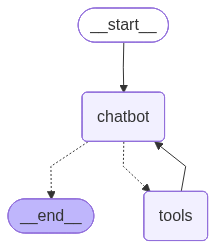

In [38]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [39]:
user_input="Hi there!, My name is John"

events=graph.stream(
     {"messages": [("user", user_input)]},stream_mode="values"
)

for event in events:
  event["messages"][-1].pretty_print()

================================ Human Message =================================

Hi there!, My name is John
================================== Ai Message ==================================

Hello John, it's nice to meet you. Is there something I can help you with or would you like to chat?


In [40]:
user_input = "what is RLHF."

# The config is the **second positional argument** to stream() or invoke()!
events = graph.stream(
    {"messages": [("user", user_input)]},stream_mode="values"
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

what is RLHF.
================================== Ai Message ==================================

RLHF stands for "Reinforcement Learning from Human Feedback." It is a technique used in artificial intelligence (AI) to fine-tune language models, particularly large language models, to improve their performance and alignment with human values.

The process of RLHF involves the following steps:

1. **Initial Model**: A large language model is pre-trained on a massive dataset, which provides a foundation for its language understanding capabilities.
2. **Human Evaluation**: Human evaluators are asked to assess the model's outputs for a given task or prompt, providing feedback in the form of rankings, ratings, or corrections.
3. **Reward Model**: A reward model is trained to predict the human evaluators' feedback, based on the model's outputs. This reward model learns to identify what makes a response "good" or "b